## Titanic Dataset

### Summary Metadata Table

| Column Name | Data Type | Short Description | Example / Allowed Values |
| :--- | :--- | :--- | :--- |
| **`survived`** | `int64` | Survival target indicator | `0` (Died), `1` (Survived) |
| **`pclass`** | `int64` | Passenger socioeconomic class | `1` (1st), `2` (2nd), `3` (3rd) |
| **`sex`** | `object` | Passenger gender | `'male'`, `'female'` |
| **`age`** | `float64` | Passenger age in years | `0.42` to `80.0` (contains NaNs) |
| **`sibsp`** | `int64` | Number of siblings / spouses aboard | `0` to `8` |
| **`parch`** | `int64` | Number of parents / children aboard | `0` to `6` |
| **`fare`** | `float64` | Passenger fare paid (ticket price) | `0.0` to `512.33` |
| **`embarked`** | `object` | Port of embarkation code | `'S'`, `'C'`, `'Q'` (contains NaNs) |
| **`class`** | `category` | Passenger class as an ordered category | `'First'`, `'Second'`, `'Third'` |
| **`who`** | `object` | Demographic classification | `'man'`, `'woman'`, `'child'` |
| **`adult_male`** | `bool` | Flag indicating if passenger is an adult male | `True`, `False` |
| **`deck`** | `category` | Cabin deck level | `'A'`, `'B'`, `'C'`, `'D'`, `'E'`, `'F'`, `'G'` (contains ~77% NaNs) |
| **`embark_town`** | `object` | Full name of embarkation port | `'Southampton'`, `'Cherbourg'`, `'Queenstown'` |
| **`alive`** | `object` | Text version of survival status | `'no'`, `'yes'` |
| **`alone`** | `bool` | Flag indicating if traveling without family | `True`, `False` |

---

### Detailed Column Breakdowns

#### 1. Primary Numerical & Target Features
* **`survived`**:
  * **Type:** Integer (`int64`)
  * **Description:** Binary target classification variable indicating whether the passenger survived the sinking.
  * **Values:** `0` = Died, `1` = Survived.
* **`pclass`**:
  * **Type:** Integer (`int64`)
  * **Description:** Ticket class proxy for socioeconomic status.
  * **Values:** `1` (Upper/1st), `2` (Middle/2nd), `3` (Lower/3rd).
* **`age`**:
  * **Type:** Continuous Float (`float64`)
  * **Description:** Age in years. Fractional values exist for infants under 1 year old.
  * **Notes:** Contains 177 missing values (~20%).
* **`fare`**:
  * **Type:** Continuous Float (`float64`)
  * **Description:** Passenger fare paid for the ticket in British pounds (£).

#### 2. Family Structure Features
* **`sibsp`** (Siblings / Spouses):
  * **Type:** Integer (`int64`)
  * **Description:** Number of siblings (brother, sister, stepbrother, stepsister) and spouses (husband, wife) traveling together.
* **`parch`** (Parents / Children):
  * **Type:** Integer (`int64`)
  * **Description:** Number of parents (mother, father) and children (daughter, son, stepdaughter, stepson) traveling together.

#### 3. Demographic & Categorical Features
* **`sex`**:
  * **Type:** String / Object (`object`)
  * **Values:** `'male'`, `'female'`.
* **`embarked`**:
  * **Type:** String / Object (`object`)
  * **Description:** Single-letter code representing the port where the passenger boarded.
  * **Values:** `'S'` = Southampton, `'C'` = Cherbourg, `'Q'` = Queenstown.
* **`who`**:
  * **Type:** String / Object (`object`)
  * **Description:** Derived demographic grouping categorizing passengers into adult men, adult women, or children (typically age < 16).
  * **Values:** `'man'`, `'woman'`, `'child'`.
* **`adult_male`**:
  * **Type:** Boolean (`bool`)
  * **Description:** Derived binary flag indicating if a passenger is an adult male (`who == 'man'`).
  * **Values:** `True`, `False`.
* **`deck`**:
  * **Type:** Categorical (`category`)
  * **Description:** Deck level where the passenger's cabin was located (A through G).
  * **Notes:** Highly sparse feature with 688 missing values (~77%).
* **`alone`**:
  * **Type:** Boolean (`bool`)
  * **Description:** Binary flag indicating if `sibsp + parch == 0`.
  * **Values:** `True` (Traveling alone), `False` (Traveling with family).

#### 4. Redundant / Duplicate Columns in Seaborn
1. **`class`** = Categorical text version of `pclass` (`'First'`, `'Second'`, `'Third'`).
2. **`embark_town`** = Full string city name of `embarked` (`'Southampton'`, `'Cherbourg'`, `'Queenstown'`).
3. **`alive`** = Text label version of `survived` (`'no'`, `'yes'`).

### 1. Project Setup & Loading Data

In [1]:
# 1. Import core packages and load data
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid') # set aesthetic style for all plots
df = sns.load_dataset('titanic') # load built-in dataset

### 2. Data Inspection & Sanity Check

In [2]:
# 2. Inspect shape and head
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns\n")
df.head()

Dataset Dimensions: 891 rows, 15 columns



,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# 3. Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [4]:
# 4. Statistical summary for numeric features
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### 3. Missing Value Audit & Data Cleaning

In [5]:
# 5. Check missing values per column
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum()/len(df)) * 100

pd.DataFrame({'Missing Count': missing_values, 'Percentage (%)': missing_percent})

,Missing Count,Percentage (%)
survived,0,0.000000
pclass,0,0.000000
sex,0,0.000000
age,177,19.865320
sibsp,0,0.000000
parch,0,0.000000
fare,0,0.000000
embarked,2,0.224467
class,0,0.000000
who,0,0.000000


columns with missing values: age, embarked, deck, embark_town

In [6]:
# 6. Clean and preprocess data safely

df_clean = df.copy() # create an independent working copy to avoid SettingsWithCopyWarnings

# fill missing 'age' values with the median age
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median()) 

# fill missing 'embarked' with the most frequent value (mode)
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean['embarked'].mode()[0]) 
# .mode() returns a series, indexing [0] extracts the single scalar value sitting at [0]

# drop 'deck' because > 75% of its data is missing
df_clean = df_clean.drop(columns=['deck'])

# drop remaining duplicate/redundant columns created by Seaborn
df_clean = df_clean.drop(columns=['embark_town', 'alive', 'class'])

# check if there are any columns with remaining values
print(f"Remaining Missing Values:\n{df_clean.isnull().sum()}") 

Remaining Missing Values:
survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
who           0
adult_male    0
alone         0
dtype: int64


embark_town is same as embarked, 
alive is same as survived, 
class is same as pclass

### 4. Univariate Analysis (Target & Demographics)

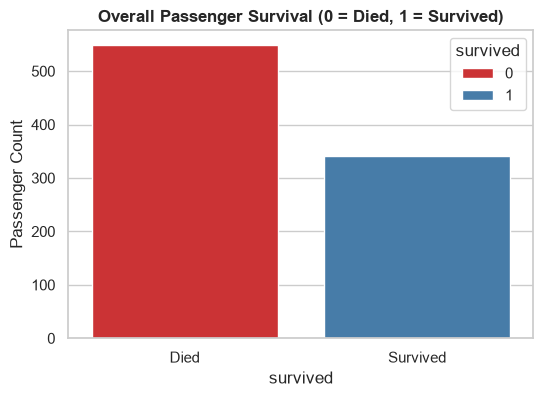

Overall Survival Rate: 38.38%


In [7]:
# 7. Survival Rate Count & Percentage

plt.figure(figsize=(6, 4)) # set canvas

ax = sns.countplot(data=df_clean, x='survived', hue ='survived', palette='Set1') # create countplot()

# add labels
plt.title('Overall Passenger Survival (0 = Died, 1 = Survived)', fontweight='bold')
plt.xticks(ticks=[0, 1], labels=['Died', 'Survived']) # what does this mean
plt.ylabel('Passenger Count')


plt.show()

print(f"Overall Survival Rate: {df_clean['survived'].mean() * 100:.2f}%") 

###### hue errors

### 5. Bivariate Analysis (Key Survival Predictors)

Explain how `sex`, `pclass` (passenger class), and `age` influenced survival odds. 

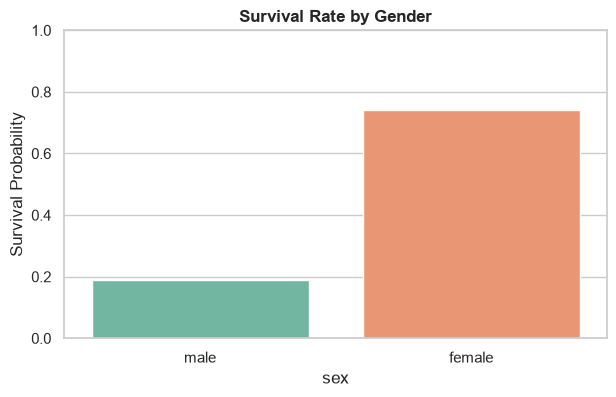

In [8]:
# 9. Survival rate by sex

plt.figure(figsize=(7, 4)) # set canvas

sns.barplot(data=df_clean, x='sex', y='survived', hue='sex', palette='Set2', errorbar=None, legend=False) # create barplot

# add chart labels
plt.title('Survival Rate by Gender', fontweight='bold')
plt.ylabel('Survival Probability')
plt.ylim(0, 1) # meaning of this

plt.show()

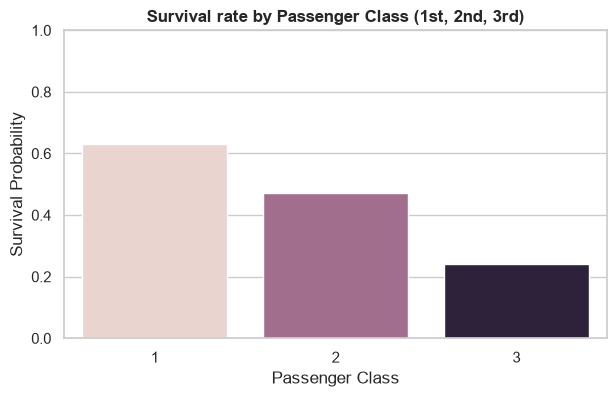

In [9]:
# 10. Survival rate by passenger class

plt.figure(figsize=(7, 4)) # set canvas

sns.barplot(data=df_clean, x='pclass', hue='pclass', y='survived', errorbar=None, legend=None) # create barplot

# add labels
plt.title('Survival rate by Passenger Class (1st, 2nd, 3rd)', fontweight='bold')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Probability')
plt.ylim(0, 1)

plt.show()

- 1 = First Class: Upper class/ Wealthy
- 2 = Second Class: Middle class / Professionals
- 3 = Third Class: Lower class / Steerage & Immigrants

### 6. Multivariate Analysis & Feature Engineering

Calculate total family members on board using `sibsp` (siblings/spouses) and `parch` (parents/children).

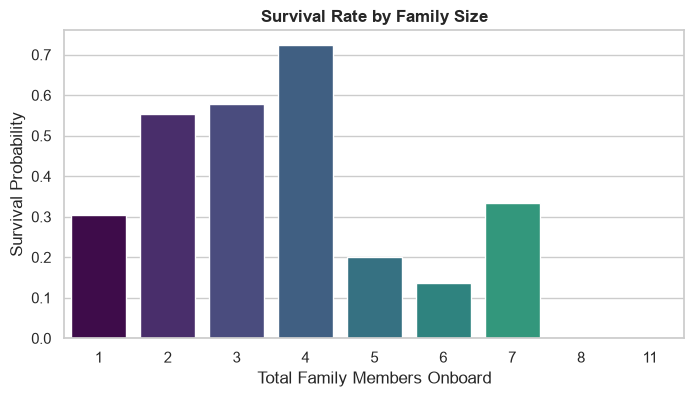

In [10]:
# 11. Create 'family_size' and 'is_alone'

df_clean['family_size'] = df_clean['sibsp'] + df_clean['parch'] + 1 # creates new column called 'family_size' that counts total number of family members travelling together on board
# sibsp = siblings + spouses on board 
# parch = parents + children on board
# +1 = the passenger themselves 

df_clean['is_alone'] = (df_clean['family_size'] == 1).astype(int) # if family_size is 1, meaning passenger is just alone (no sibsp, no parch)

# plot survival by family size
plt.figure(figsize=(8, 4)) # set canvas
sns.barplot(data=df_clean, x='family_size', hue = 'family_size', y='survived', palette='viridis', errorbar=None, legend=None) # create barplot

# labels
plt.title('Survival Rate by Family Size', fontweight='bold')
plt.xlabel('Total Family Members Onboard')
plt.ylabel('Survival Probability')

plt.show()

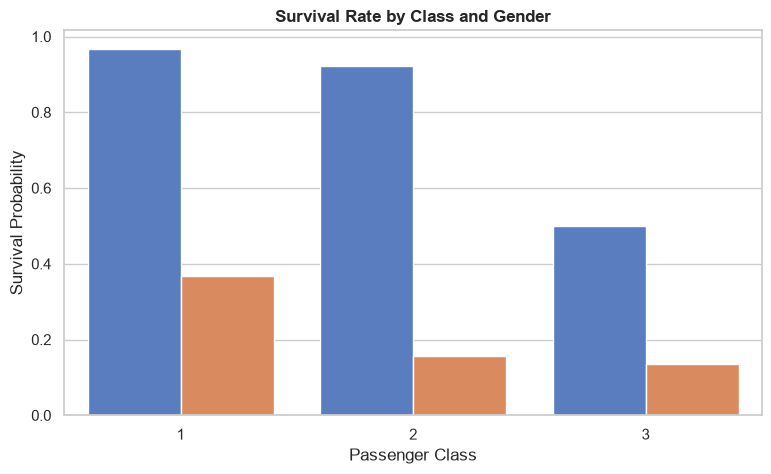

In [11]:
# 12. Survival rate across Class AND Gender combined

plt.figure(figsize=(9, 5)) # set canvas
sns.barplot(data=df_clean, x='pclass', y='survived', hue='sex', palette='muted', errorbar=None, legend=None) # create barplot

# set labels
plt.title('Survival Rate by Class and Gender', fontweight='bold')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Probability')
plt.show()

### 7. Correlation Heatmap

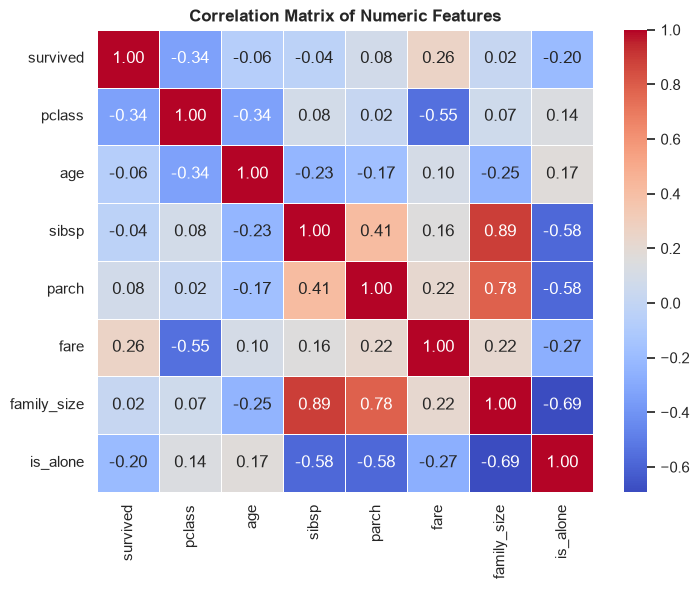

In [12]:
# 13. Heatmap of numerical correlations

plt.figure(figsize=(8, 6)) # set canvas
numeric_df = df_clean.select_dtypes(include=[np.number]) # what does this mean?
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Matrix of Numeric Features', fontweight='bold')

plt.show()

### 8. Executive Summary & Analytical Findings

1. **Gender Disparity:** Gender was the single strongest predictor of survival. Female passengers had a ~74% survival rate, whereas male passengers had a ~19% survival rate *(see Barplot: Survival Rate by Gender)*.
2. **Socioeconomic Status:** 1st Class passengers had a significantly higher chance of survival (~63%) compared to 3rd Class passengers (~24%) *(see Barplot: Survival Rate by Passenger Class)*.
3. **Compounding Advantage:** 1st and 2nd class females survived at rates above 90%, whereas 3rd class males suffered the highest mortality *(see Barplot: Survival Rate by Class and Gender)*.
4. **Family Size Dynamics:** Passengers traveling completely alone or with very large families (>4) had lower survival rates compared to small families of 2 to 4 members *(see Barplot: Survival Rate by Family Size)*.